# Combined Chromatin Model - Positive Controls
February 9, 2024

Deconvolve the positive controls with the combined model


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [27]:
def deconvolve_gene(gene_name, save_dir):
    """
    Deconvolve a gene's gene expression and chromatin
    """
    from src.model import Model
    from cc_src.chromatin_model import ChromatinModel
    from src.config import load_yl_replicate1_rg1_alpha_vst_config, \
        load_yl_replicate2_rg1_alpha_vst_config

    # Load the config for each model
    ge_config = load_combined_yl_alpha_vst_gene_expression_config()
    config1 = load_yl_replicate1_rg1_alpha_vst_config()
    config2 = load_yl_replicate2_rg1_alpha_vst_config()

    print(f"Deconvolving {gene_name}, combined model")
    print(f"Deconvolving gene expression...", end="")
    ge_model = Model(ge_config, gene_name)
    ge_model.deconvolve_find_optimal_gamma()
    print("Done.")

    print(f"Deconvolving chromatin...", end="")
    combined_model = CombinedChromatinModel(config1, config2)
    combined_model.load_combined_mnase_gene(gene_name)
    combined_model.deconvolve_find_optimal_gamma()
    print("Done.")
    
    save_name = f"{save_dir}/{gene_name}_combined_chromatin.png"
    fig = combined_model.create_deconvolution_plots_abbreviated_flipped(ge_model)
    plt.savefig(save_name, dpi=200)
    print(f"Saved figure to {save_name}")
    plt.close(fig)

    save_name = f"{save_dir}/{gene_name}_combined_rep1_predicted.png"
    fig = combined_model.plot_raw_prediction(1)
    plt.savefig(save_name, dpi=200)
    print(f"Saved figure to {save_name}")
    plt.close(fig)

    save_name = f"{save_dir}/{gene_name}_combined_rep2_predicted.png"
    fig = combined_model.plot_raw_prediction(2)
    plt.savefig(save_name, dpi=200)
    print(f"Saved figure to {save_name}")
    plt.close(fig)


In [29]:
from cc_src.geneset import positive_control_genes
from src.timer import Timer

timer = Timer()
save_dir = 'output/positive_controls_chromatin/combined'
genes = positive_control_genes()
total = len(genes)
count = 0
for gene_name in genes:
    deconvolve_gene(gene_name, save_dir)
    count += 1
    print(f"\n===== Progress {count}/{total} - {timer.get_time()}\n\n")


Deconvolving CLB2, combined model
Deconvolving gene expression...Done.
Deconvolving chromatin...Loading MNase reads for CLB2...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the flattened grid to be deconvolved is: (16, 27)
Applying normalization using scaling matrix: output/mnase/rep1_len_scaling_3len_bins.csv
The shape of the flattened grid to be deconvolved is: (16, 27)
Loading MNase reads for CLB2...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the flattened grid to be deconvolved is: (15, 27)
Applying normalization using scaling matrix: output/mnase/rep2_len_scaling_3len_bins.csv
The shape of the flattened grid to be deconvolved is: (15, 27)
Running the find optimal gamma procedure...
  ... The base fitting norm (rn) with no smoothing (gamma=0) is: 1.8177
  ... Searching for an optimal gamma value in the boundaries: [0.0001, 0.0100]
  ...  search left, rn_goal = 1.8977, rate = 4.4
  ...   gm = 0.0050, rn = 2.1792, rate = 19.89, time = 00:00:39.

/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/cvxpy/problems/problem.py:1403: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


  ...   gm = 0.0050, rn = 1.9235, rate = 12.85, time = 00:01:52.61
  ...   gm = 0.0026, rn = 1.8372, rate = 7.78, time = 00:02:39.85
  ...  search right, rn_goal = 2.3864, rate = 40.0
  ... rn range: [1.7855, 2.0575]
  ... search gamma in [0.0013 0.0100] for elbow
  ...   gm = 0.0013, rn = 1.7855, rate = 4.75, time = 00:04:55.42
  ...   gm = 0.0022, rn = 1.8239, rate = 7.00, time = 00:05:41.71
  ...   gm = 0.0031, rn = 1.8514, rate = 8.61, time = 00:06:30.16
  ...   gm = 0.0039, rn = 1.8849, rate = 10.58, time = 00:07:18.97
  ...   gm = 0.0048, rn = 1.9132, rate = 12.24, time = 00:08:07.33
  ...   gm = 0.0057, rn = 1.9440, rate = 14.05, time = 00:08:54.53
  ...   gm = 0.0065, rn = 1.9715, rate = 15.66, time = 00:09:41.96
  ...   gm = 0.0074, rn = 1.9973, rate = 17.17, time = 00:10:26.54
  ...   gm = 0.0083, rn = 2.0196, rate = 18.49, time = 00:11:08.48
  ...   gm = 0.0091, rn = 2.0392, rate = 19.64, time = 00:11:50.36
  ...   gm = 0.0100, rn = 2.0575, rate = 20.71, time = 00:12:31.59
T

/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/cvxpy/problems/problem.py:1403: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


  ...   gm = 0.0050, rn = 5.3456, rate = 4.68, time = 00:01:48.57
  ...   gm = 0.0026, rn = 5.2904, rate = 3.60, time = 00:02:35.87
  ...   gm = 0.0013, rn = 5.2410, rate = 2.64, time = 00:03:24.51
  ...  search right, rn_goal = 7.1489, rate = 40.0
  ... rn range: [5.2410, 5.4104]
  ... search gamma in [0.0013 0.0100] for elbow
  ...   gm = 0.0013, rn = 5.2410, rate = 2.64, time = 00:04:58.55
  ...   gm = 0.0022, rn = 5.2771, rate = 3.34, time = 00:05:46.18
  ...   gm = 0.0031, rn = 5.3023, rate = 3.84, time = 00:06:33.26
  ...   gm = 0.0039, rn = 5.3195, rate = 4.17, time = 00:07:21.12
  ...   gm = 0.0048, rn = 5.3416, rate = 4.61, time = 00:08:07.94
  ...   gm = 0.0057, rn = 5.3564, rate = 4.90, time = 00:08:54.22
  ...   gm = 0.0065, rn = 5.3686, rate = 5.14, time = 00:09:41.00
  ...   gm = 0.0074, rn = 5.3798, rate = 5.35, time = 00:10:28.17
  ...   gm = 0.0083, rn = 5.3916, rate = 5.59, time = 00:11:15.74
  ...   gm = 0.0091, rn = 5.4020, rate = 5.79, time = 00:12:02.66
  ...   gm

...

/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/cvxpy/problems/problem.py:1403: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


  ...   gm = 0.0050, rn = 4.7965, rate = 3.29, time = 00:01:48.72
  ...   gm = 0.0026, rn = 4.7465, rate = 2.22, time = 00:02:36.54
  ...   gm = 0.0013, rn = 4.6963, rate = 1.14, time = 00:03:23.11
  ...  search right, rn_goal = 6.5010, rate = 40.0
  ... rn range: [4.6963, 4.8930]
  ... search gamma in [0.0013 0.0100] for elbow
  ...   gm = 0.0013, rn = 4.6963, rate = 1.14, time = 00:04:54.81
  ...   gm = 0.0022, rn = 4.7405, rate = 2.09, time = 00:05:39.74
  ...   gm = 0.0031, rn = 4.7558, rate = 2.42, time = 00:06:24.25
  ...   gm = 0.0039, rn = 4.7730, rate = 2.79, time = 00:07:08.96
  ...   gm = 0.0048, rn = 4.7921, rate = 3.20, time = 00:07:53.81
  ...   gm = 0.0057, rn = 4.8156, rate = 3.70, time = 00:08:37.89
  ...   gm = 0.0065, rn = 4.8303, rate = 4.02, time = 00:09:21.87
  ...   gm = 0.0074, rn = 4.8537, rate = 4.52, time = 00:10:06.57
  ...   gm = 0.0083, rn = 4.8677, rate = 4.83, time = 00:10:51.47
  ...   gm = 0.0091, rn = 4.8804, rate = 5.10, time = 00:11:36.05
  ...   gm

/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/cvxpy/problems/problem.py:1403: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


  ...   gm = 0.0026, rn = 2.3379, rate = 4.88, time = 00:02:33.93
  ...   gm = 0.0013, rn = 2.3012, rate = 3.24, time = 00:03:22.30
  ...  search right, rn_goal = 3.1207, rate = 40.0
  ... rn range: [2.3012, 2.4771]
  ... search gamma in [0.0013 0.0100] for elbow
  ...   gm = 0.0013, rn = 2.3012, rate = 3.24, time = 00:04:59.17
  ...   gm = 0.0022, rn = 2.3355, rate = 4.78, time = 00:05:47.06
  ...   gm = 0.0031, rn = 2.3545, rate = 5.63, time = 00:06:36.08
  ...   gm = 0.0039, rn = 2.3744, rate = 6.52, time = 00:07:24.64
  ...   gm = 0.0048, rn = 2.3915, rate = 7.29, time = 00:08:12.52
  ...   gm = 0.0057, rn = 2.4100, rate = 8.12, time = 00:09:00.25
  ...   gm = 0.0065, rn = 2.4258, rate = 8.83, time = 00:09:48.47
  ...   gm = 0.0074, rn = 2.4404, rate = 9.48, time = 00:10:36.63
  ...   gm = 0.0083, rn = 2.4530, rate = 10.05, time = 00:11:26.01
  ...   gm = 0.0091, rn = 2.4644, rate = 10.56, time = 00:12:14.27
  ...   gm = 0.0100, rn = 2.4771, rate = 11.13, time = 00:13:03.59
The x_g

Loading MNase reads for DSE4...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the flattened grid to be deconvolved is: (15, 27)
Applying normalization using scaling matrix: output/mnase/rep2_len_scaling_3len_bins.csv
The shape of the flattened grid to be deconvolved is: (15, 27)
Running the find optimal gamma procedure...
  ... The base fitting norm (rn) with no smoothing (gamma=0) is: 1.1922
  ... Searching for an optimal gamma value in the boundaries: [0.0001, 0.0100]
  ...  search left, rn_goal = 1.2722, rate = 6.7
  ...   gm = 0.0050, rn = 1.4139, rate = 18.60, time = 00:00:38.63
  ...   gm = 0.0026, rn = 1.3518, rate = 13.39, time = 00:00:48.99
  ...   gm = 0.0013, rn = 1.3035, rate = 9.34, time = 00:00:58.79
  ...  search right, rn_goal = 1.6690, rate = 40.0
  ... rn range: [1.3035, 1.4825]
  ... search gamma in [0.0013 0.0100] for elbow
  ...   gm = 0.0013, rn = 1.3035, rate = 9.34, time = 00:01:19.50
  ...   gm = 0.0022, rn = 1.3409, rate = 12.48, time = 00:01

In [30]:
from cc_src.geneset import cyclin_genes
from src.timer import Timer

timer = Timer()
save_dir = 'output/positive_controls_chromatin/combined'
genes = cyclin_genes()
total = len(genes)
count = 0
for gene_name in genes:
    deconvolve_gene(gene_name, save_dir)
    count += 1
    print(f"\n===== Progress {count}/{total} - {timer.get_time()}\n\n")


Deconvolving CLN1, combined model
Deconvolving gene expression...Done.
Deconvolving chromatin...Loading MNase reads for CLN1...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the flattened grid to be deconvolved is: (16, 27)
Applying normalization using scaling matrix: output/mnase/rep1_len_scaling_3len_bins.csv
The shape of the flattened grid to be deconvolved is: (16, 27)
Loading MNase reads for CLN1...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the flattened grid to be deconvolved is: (15, 27)
Applying normalization using scaling matrix: output/mnase/rep2_len_scaling_3len_bins.csv
The shape of the flattened grid to be deconvolved is: (15, 27)
Running the find optimal gamma procedure...
  ... The base fitting norm (rn) with no smoothing (gamma=0) is: 1.5828
  ... Searching for an optimal gamma value in the boundaries: [0.0001, 0.0100]
  ...  search left, rn_goal = 1.6628, rate = 5.1
  ...   gm = 0.0050, rn = 1.8175, rate = 14.83, time = 00:00:40.

The curvature is: [5.88968218e-05 1.31317648e-04 3.96124544e-04 8.16774233e-04
 2.81112117e-03 1.86804876e-03 4.67329015e-04 5.68336390e-04
 1.61322068e-03 2.10361891e-03 1.75090504e-03]
YAL040C: ... final gamma = 0.00480
Time to find optimal gamma: 00:19:41.63
Deconvolved in : 00:19:44.20
The fitting norm is 1.82, the smoothing norm is: 22.71
Done.
Saved figure to output/positive_controls_chromatin/combined/CLN3_combined_chromatin.png
Saved figure to output/positive_controls_chromatin/combined/CLN3_combined_rep1_predicted.png
Saved figure to output/positive_controls_chromatin/combined/CLN3_combined_rep2_predicted.png

===== Progress 3/9 - 00:41:02.31


Deconvolving CLB5, combined model
Deconvolving gene expression...Done.
Deconvolving chromatin...Loading MNase reads for CLB5...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the flattened grid to be deconvolved is: (16, 27)
Applying normalization using scaling matrix: output/mnase/rep1_len_scaling_3len_bins.csv
The sha

/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/cvxpy/problems/problem.py:1403: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


  ...   gm = 0.0050, rn = 2.9599, rate = 3.50, time = 00:14:10.48
  ...   gm = 0.0026, rn = 2.8205, rate = -1.37, time = 00:25:44.52
  ...   gm = 0.0038, rn = 3.0908, rate = 8.08, time = 00:27:40.23
  ...  search right, rn_goal = 4.0035, rate = 40.0
  ... rn range: [3.0908, 3.1112]
  ... search gamma in [0.0038 0.0100] for elbow
  ...   gm = 0.0038, rn = 3.0908, rate = 8.08, time = 00:29:18.60
  ...   gm = 0.0044, rn = 3.0463, rate = 6.53, time = 00:35:21.29
  ...   gm = 0.0051, rn = 3.0280, rate = 5.89, time = 00:36:10.14
  ...   gm = 0.0057, rn = 3.0306, rate = 5.98, time = 00:36:59.89
  ...   gm = 0.0063, rn = 3.0257, rate = 5.81, time = 00:43:38.14
  ...   gm = 0.0069, rn = 2.9895, rate = 4.54, time = 00:44:28.33
  ...   gm = 0.0075, rn = 3.1180, rate = 9.04, time = 00:50:28.86
  ...   gm = 0.0081, rn = 3.0797, rate = 7.69, time = 00:51:18.01
  ...   gm = 0.0088, rn = 3.2339, rate = 13.09, time = 00:52:07.73
  ...   gm = 0.0094, rn = 3.2598, rate = 13.99, time = 00:55:24.22
  ...  

Running the find optimal gamma procedure...
  ... The base fitting norm (rn) with no smoothing (gamma=0) is: 1.8177
  ... Searching for an optimal gamma value in the boundaries: [0.0001, 0.0100]
  ...  search left, rn_goal = 1.8977, rate = 4.4
  ...   gm = 0.0050, rn = 2.1792, rate = 19.89, time = 00:00:38.46
  ...   gm = 0.0026, rn = 2.0848, rate = 14.70, time = 00:00:48.65
  ...   gm = 0.0013, rn = 1.9994, rate = 10.00, time = 00:00:57.80
  ...  search right, rn_goal = 2.5448, rate = 40.0
  ... rn range: [1.9994, 2.2844]
  ... search gamma in [0.0013 0.0100] for elbow
  ...   gm = 0.0013, rn = 1.9994, rate = 10.00, time = 00:01:16.01
  ...   gm = 0.0022, rn = 2.0626, rate = 13.47, time = 00:01:25.73
  ...   gm = 0.0031, rn = 2.1108, rate = 16.13, time = 00:01:35.42
  ...   gm = 0.0039, rn = 2.1511, rate = 18.34, time = 00:01:45.13
  ...   gm = 0.0048, rn = 2.1734, rate = 19.57, time = 00:01:54.41
  ...   gm = 0.0057, rn = 2.1954, rate = 20.78, time = 00:02:33.96
  ...   gm = 0.0065, 

/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/cvxpy/problems/problem.py:1403: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


  ...   gm = 0.0050, rn = 4.3655, rate = 3.08, time = 00:10:35.44
  ...   gm = 0.0026, rn = 4.3067, rate = 1.69, time = 00:11:23.80
  ...   gm = 0.0038, rn = 4.3533, rate = 2.79, time = 00:12:13.19
  ...  search right, rn_goal = 5.9290, rate = 40.0
  ... rn range: [4.3533, 4.4677]
  ... search gamma in [0.0038 0.0100] for elbow
  ...   gm = 0.0038, rn = 4.3533, rate = 2.79, time = 00:28:49.57
  ...   gm = 0.0044, rn = 4.3634, rate = 3.03, time = 00:29:38.09
  ...   gm = 0.0051, rn = 4.3736, rate = 3.27, time = 00:46:25.67
  ...   gm = 0.0057, rn = 4.4021, rate = 3.95, time = 00:47:13.55
  ...   gm = 0.0063, rn = 4.3980, rate = 3.85, time = 01:03:22.11
  ...   gm = 0.0069, rn = 4.4062, rate = 4.04, time = 01:04:10.40
  ...   gm = 0.0075, rn = 4.4194, rate = 4.36, time = 01:04:58.89
  ...   gm = 0.0081, rn = 4.4101, rate = 4.14, time = 01:20:46.53
  ...   gm = 0.0088, rn = 4.4454, rate = 4.97, time = 01:21:34.47
  ...   gm = 0.0094, rn = 4.4568, rate = 5.24, time = 01:22:23.26
  ...   gm

In [31]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config

config1 = load_yl_replicate1_rg1_alpha_vst_config()
chromatin_model = ChromatinModel(config=config1)


In [34]:
chromatin_model.load_mnase_gene('CLB2', replicate=1)

Loading MNase reads for CLB2...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the flattened grid to be deconvolved is: (16, 27)
Applying normalization using scaling matrix: output/mnase/rep1_len_scaling_3len_bins.csv
The shape of the flattened grid to be deconvolved is: (16, 27)


In [171]:
chromatin_model.gamma = 0.001
chromatin_model.deconvolve()

Deconvolved in : 00:00:08.14
The fitting norm is 0.91, the smoothing norm is: 50.71


In [162]:
chromatin_model.deconvolve_find_optimal_gamma()

Running the find optimal gamma procedure...
  ... The base fitting norm (rn) with no smoothing (gamma=0) is: 0.8318
  ... Searching for an optimal gamma value in the boundaries: [0.0001, 0.0100]
  ...  search left, rn_goal = 0.9118, rate = 9.6


/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/cvxpy/problems/problem.py:1403: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


  ...   gm = 0.0050, rn = 1.0323, rate = 24.11, time = 00:00:50.18
  ...   gm = 0.0026, rn = 0.9649, rate = 16.00, time = 00:00:57.19
  ...   gm = 0.0013, rn = 0.9233, rate = 11.01, time = 00:01:04.41
  ...  search right, rn_goal = 1.1645, rate = 40.0
  ... rn range: [0.9233, 1.1355]
  ... search gamma in [0.0013 0.0100] for elbow
  ...   gm = 0.0013, rn = 0.9233, rate = 11.01, time = 00:01:18.43
  ...   gm = 0.0022, rn = 0.9540, rate = 14.69, time = 00:01:25.49
  ...   gm = 0.0031, rn = 0.9810, rate = 17.94, time = 00:01:32.28
  ...   gm = 0.0039, rn = 1.0030, rate = 20.59, time = 00:01:39.41
  ...   gm = 0.0048, rn = 1.0257, rate = 23.31, time = 00:01:46.05
  ...   gm = 0.0057, rn = 1.0485, rate = 26.06, time = 00:01:52.76
  ...   gm = 0.0065, rn = 1.0660, rate = 28.15, time = 00:01:59.44
  ...   gm = 0.0074, rn = 1.0862, rate = 30.58, time = 00:02:06.42
  ...   gm = 0.0083, rn = 1.1050, rate = 32.84, time = 00:02:13.20
  ...   gm = 0.0091, rn = 1.1214, rate = 34.82, time = 00:02:20.

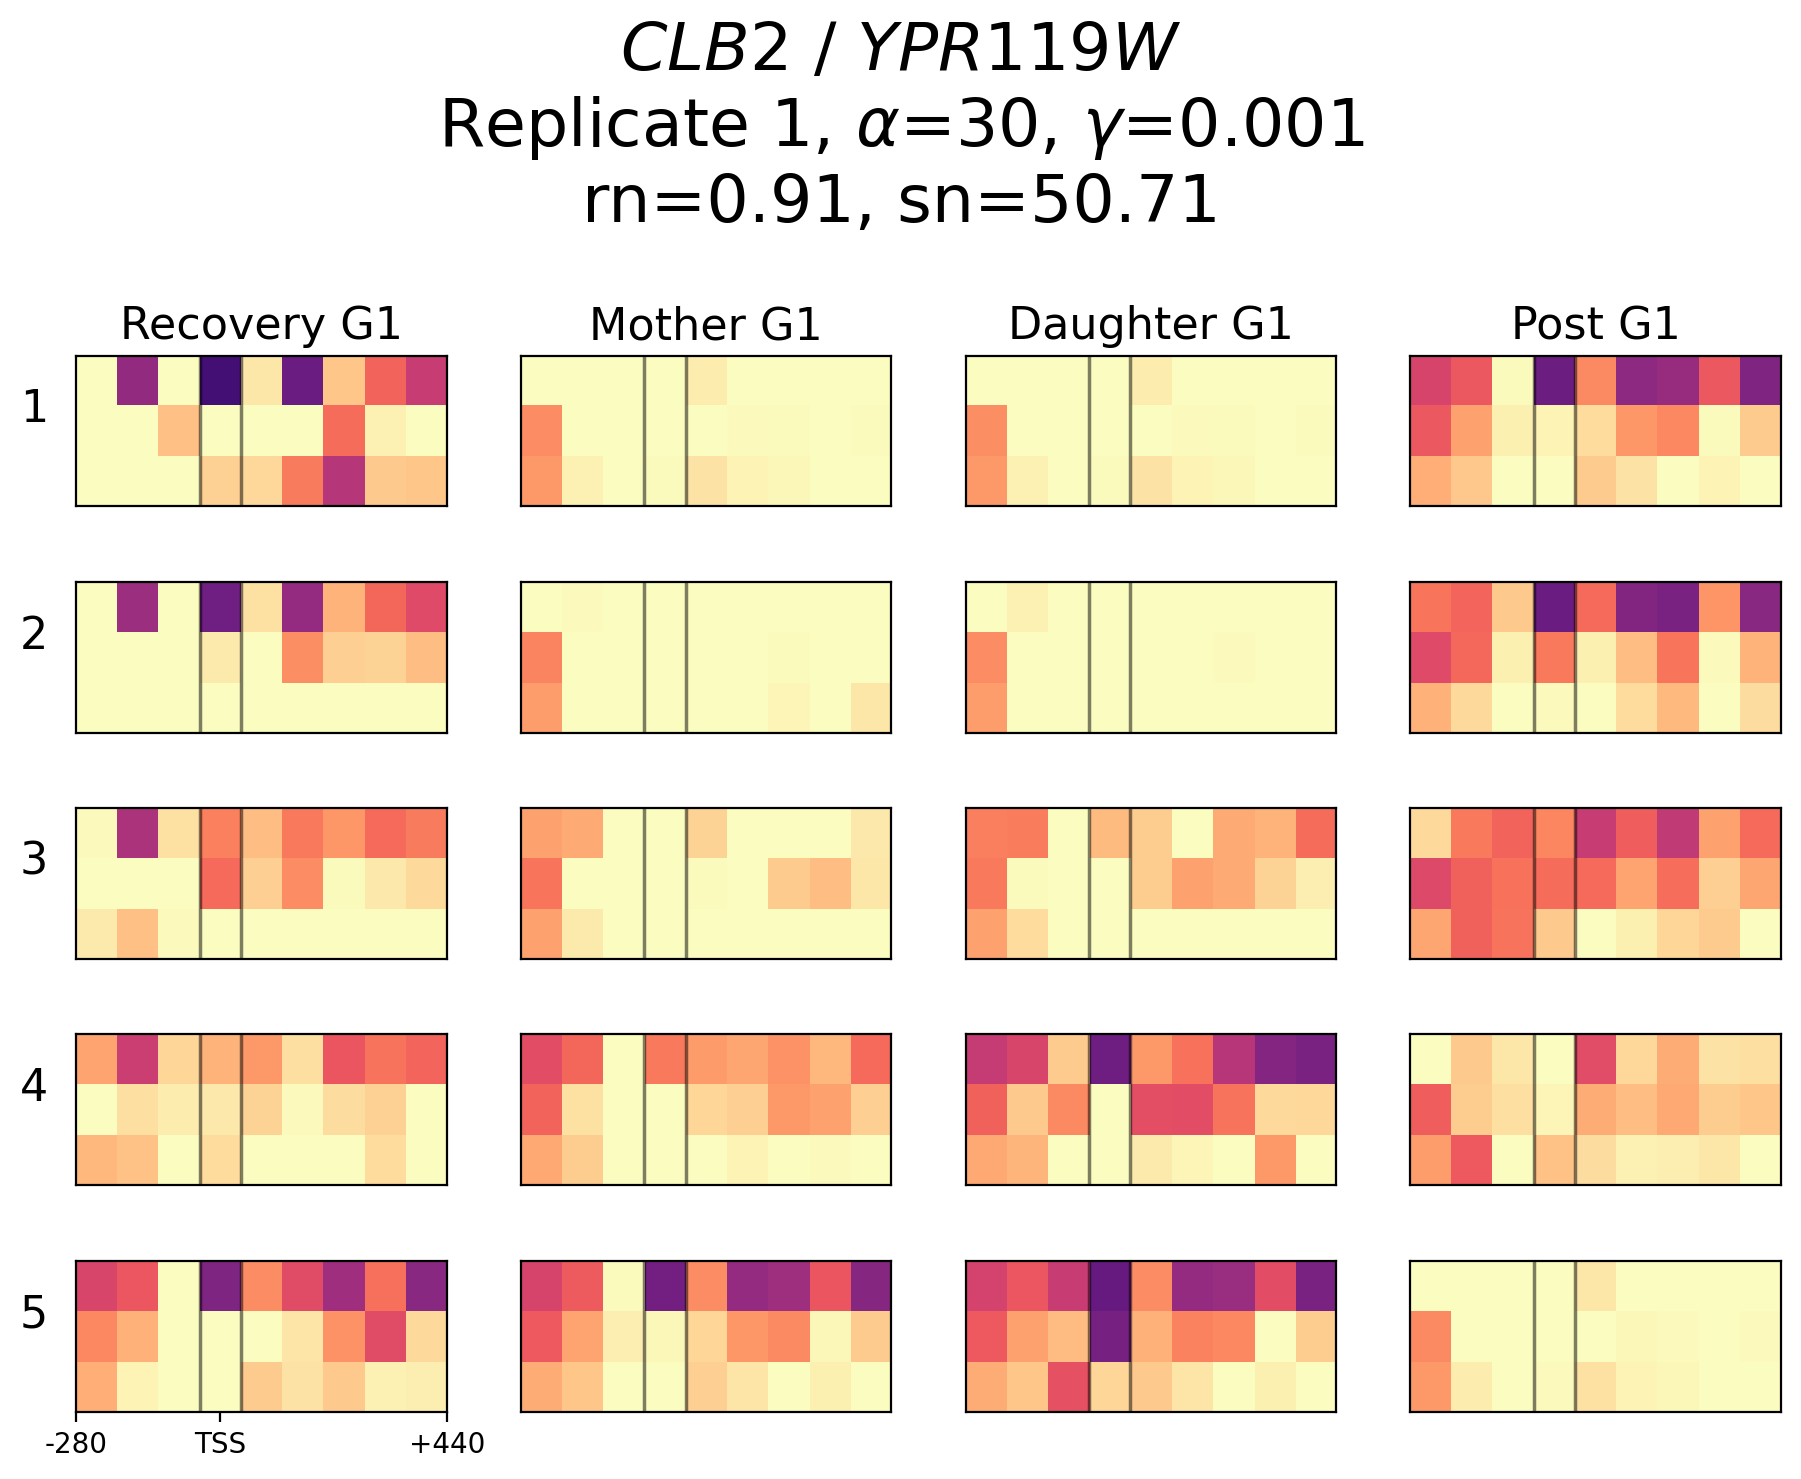

In [172]:
fig = chromatin_model.create_deconvolution_plots_abbreviated_flipped()